<a href="https://colab.research.google.com/github/sjlee53/ESAA-submission/blob/main/week3/0916_ESAA_YB_kaggle_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')      # 드라이브 연결 (허용 창이 뜨면 허용)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os
color = sns.color_palette()
%matplotlib inline

Mounted at /content/drive


In [2]:
found = glob.glob("/content/drive/MyDrive/26-2*/*/orders.csv")
print(found)
DATA = os.path.dirname(found[0])

aisles_df      = pd.read_csv(f"{DATA}/aisles.csv")
departments_df = pd.read_csv(f"{DATA}/departments.csv")
products_df    = pd.read_csv(f"{DATA}/products.csv")
orders_df      = pd.read_csv(f"{DATA}/orders.csv")
order_products_train_df = pd.read_csv(f"{DATA}/order_products__train.csv")
order_products_prior_df = pd.read_csv(
    f"{DATA}/order_products__prior.csv",
    dtype={'order_id': 'int32', 'product_id': 'int32',
           'add_to_cart_order': 'int16', 'reordered': 'int8'}
)

print(orders_df.shape, order_products_prior_df.shape)

['/content/drive/MyDrive/26-2 교재/YB 3주차 캐글 필사과제 Instacart 데이터/orders.csv']
(3421083, 7) (32434489, 4)


In [5]:
orders_df.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [6]:
order_products_prior_df.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [7]:
order_products_train_df.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


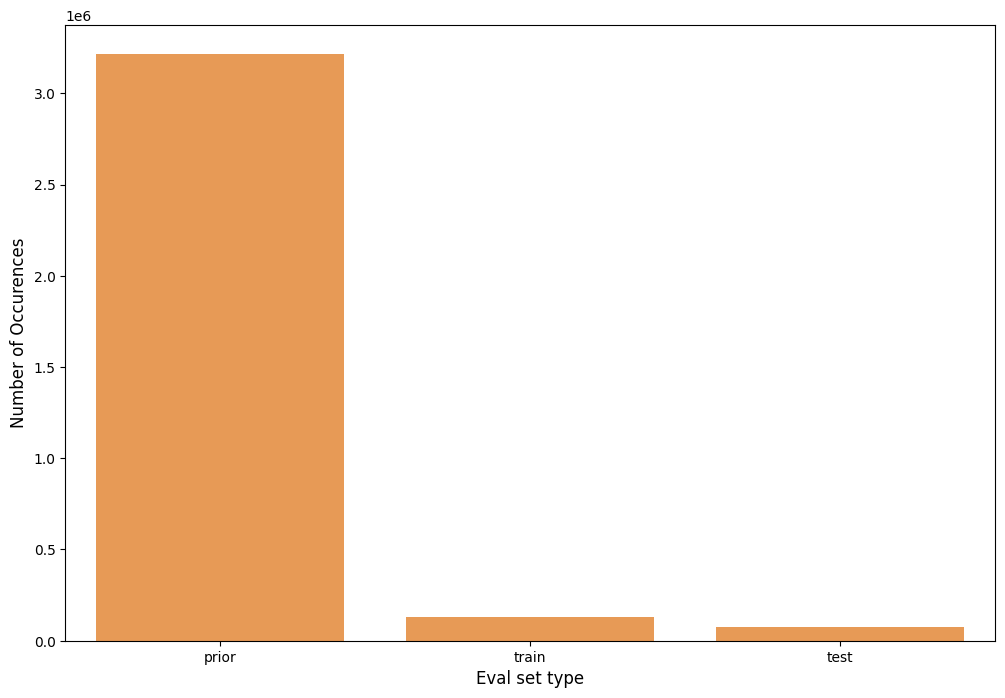

In [8]:
cnt_srs = orders_df.eval_set.value_counts()
plt.figure(figsize=(12, 8))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha=0.8, color=color[1])
plt.ylabel('Number of Occurences', fontsize=12)
plt.xlabel('Eval set type', fontsize=12)
plt.show()

In [9]:
def get_unique_count(x):
  return len(np.unique(x))
cnt_srs=orders_df.groupby('eval_set')['user_id'].aggregate(get_unique_count)
cnt_srs

,user_id
eval_set,
prior,206209
test,75000
train,131209


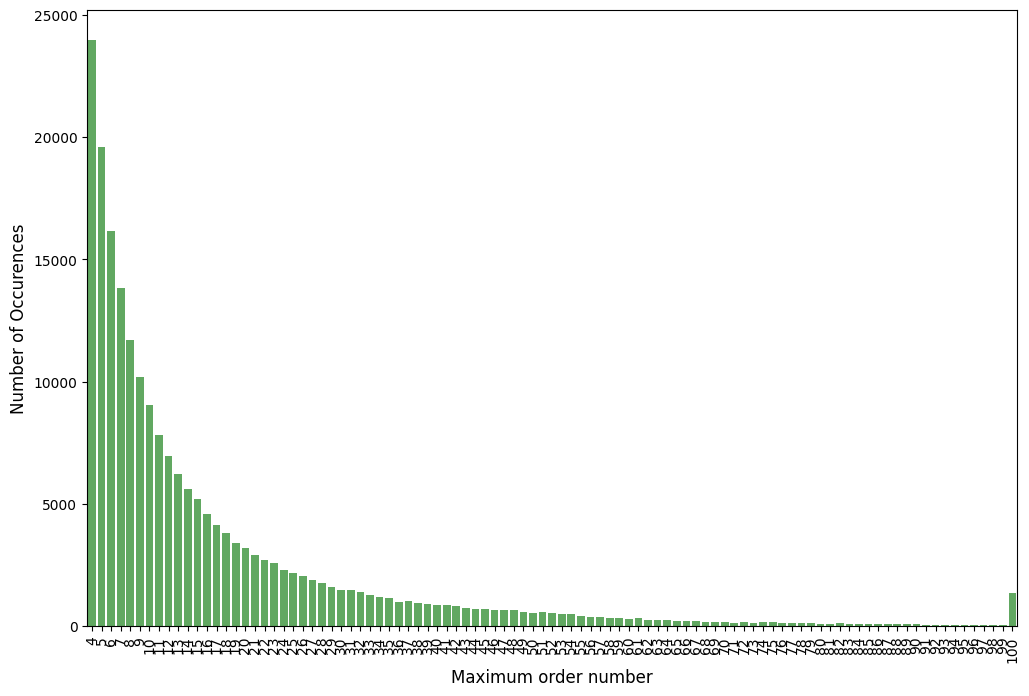

In [10]:
cnt_srs = orders_df.groupby('user_id')['order_number'].max().reset_index()
cnt_srs = cnt_srs.order_number.value_counts()
plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index,y=cnt_srs.values,alpha=0.8,color=color[2])
plt.ylabel('Number of Occurences',fontsize=12)
plt.xlabel('Maximum order number',fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

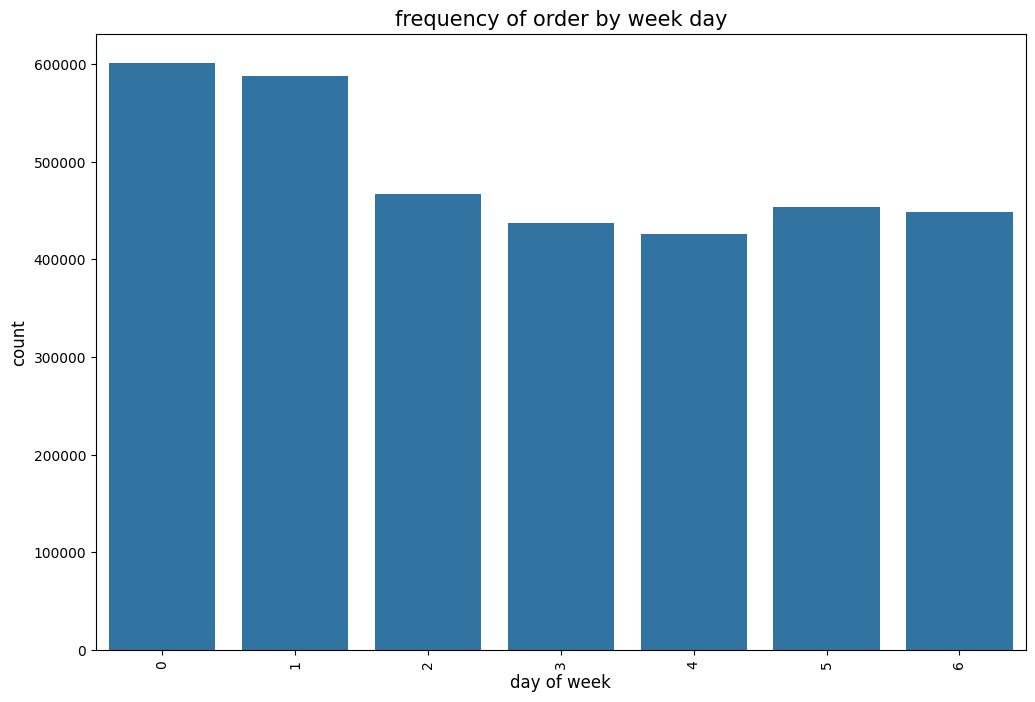

In [11]:
plt.figure(figsize=(12,8))
sns.countplot(x='order_dow',data=orders_df,color=color[0])
plt.ylabel('count',fontsize=12)
plt.xlabel('day of week',fontsize=12)
plt.xticks(rotation='vertical')
plt.title('frequency of order by week day', fontsize=15)
plt.show()

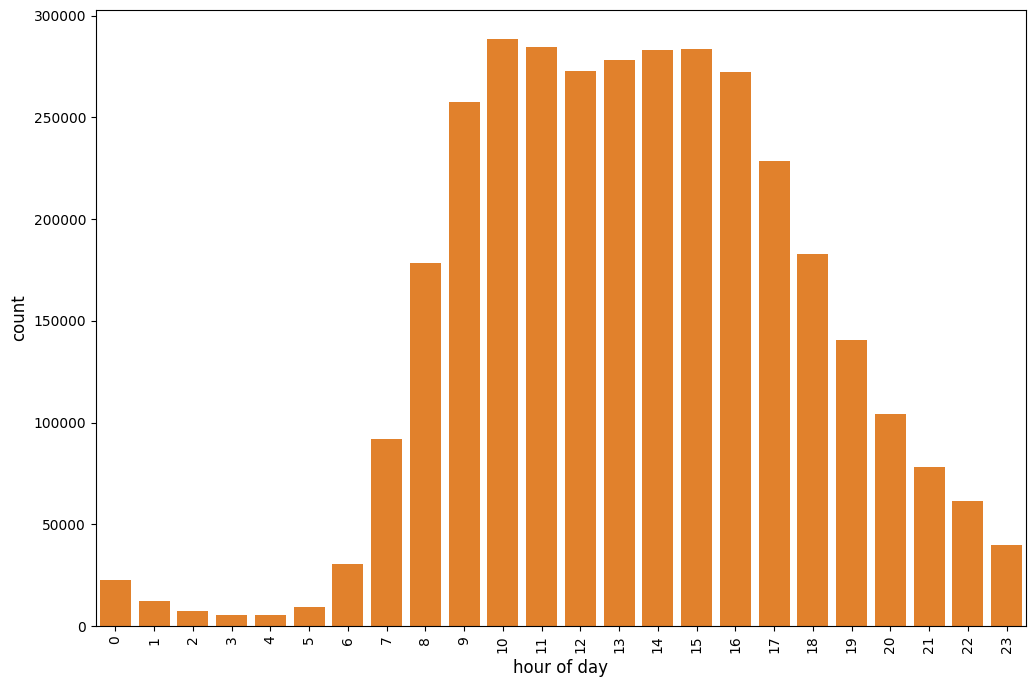

In [12]:
plt.figure(figsize=(12,8))
sns.countplot(x='order_hour_of_day',data=orders_df,color=color[1])
plt.ylabel('count',fontsize=12)
plt.xlabel('hour of day',fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

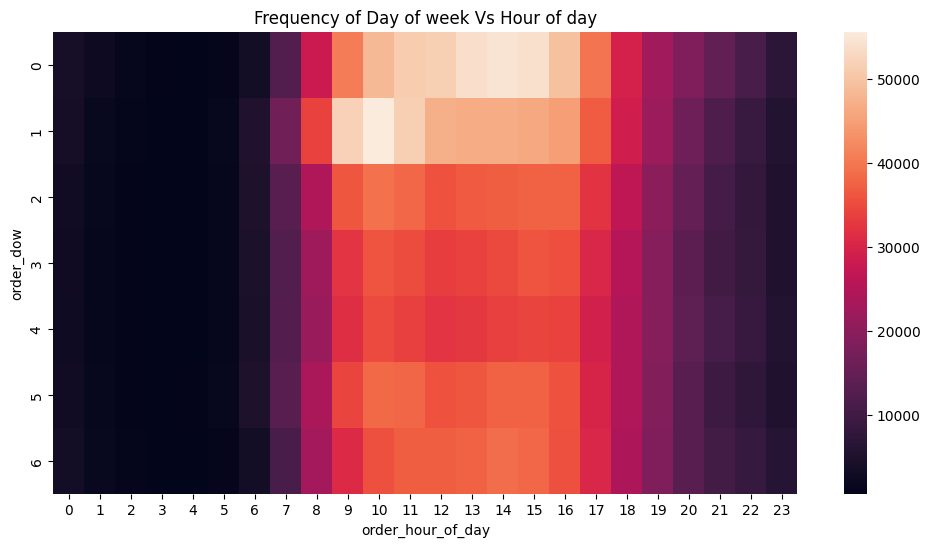

In [13]:
grouped_df = orders_df.groupby(['order_dow', 'order_hour_of_day'])['order_number'].aggregate('count').reset_index()
grouped_df = grouped_df.pivot(index='order_dow', columns='order_hour_of_day', values='order_number')
plt.figure(figsize=(12, 6))
sns.heatmap(grouped_df)
plt.title('Frequency of Day of week Vs Hour of day')
plt.show()

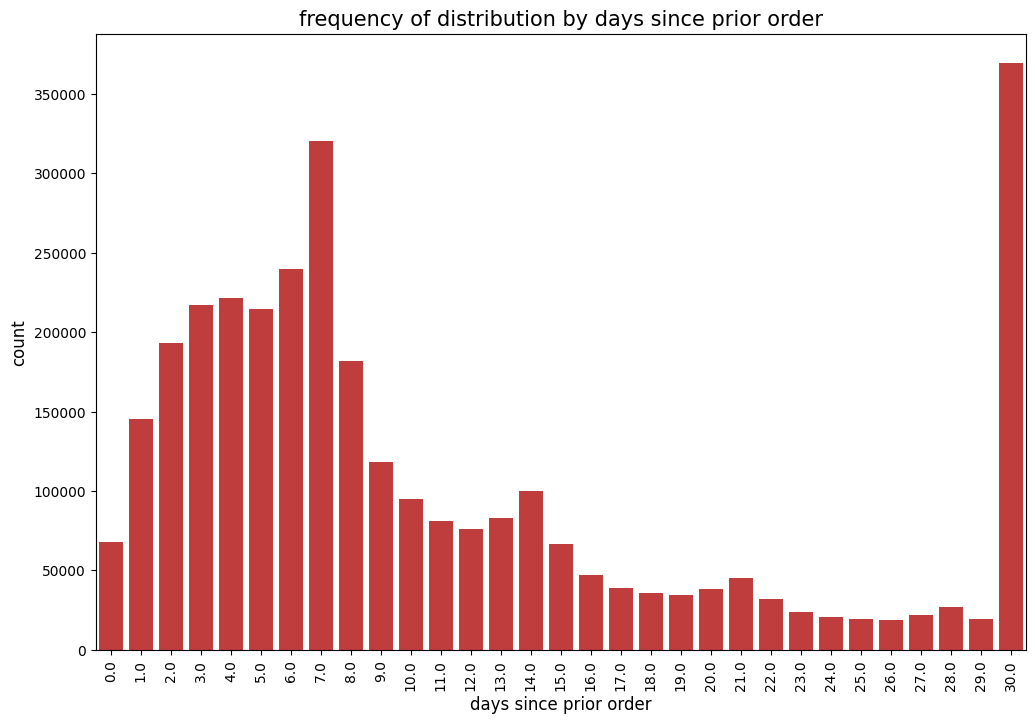

In [27]:
plt.figure(figsize=(12,8))
sns.countplot(x='days_since_prior_order',data=orders_df,color=color[3])
plt.ylabel('count',fontsize=12)
plt.xlabel('days since prior order',fontsize=12)
plt.xticks(rotation='vertical')
plt.title('frequency of distribution by days since prior order',fontsize=15)
plt.show()

In [14]:
#percentage of re-orders imprior set
order_products_prior_df.reordered.sum()/order_products_prior_df.shape[0]

np.float64(0.5896974667922161)

In [15]:
#percentage of re-orders in train set
order_products_train_df.reordered.sum()/order_products_train_df.shape[0]

np.float64(0.5985944127509629)

In [16]:
grouped_df = order_products_prior_df.groupby('order_id')['reordered'].aggregate('sum').reset_index()
grouped_df.loc[grouped_df['reordered'] > 1, 'reordered'] = 1
grouped_df.reordered.value_counts() / grouped_df.shape[0]

,count
reordered,
1,0.879151
0,0.120849


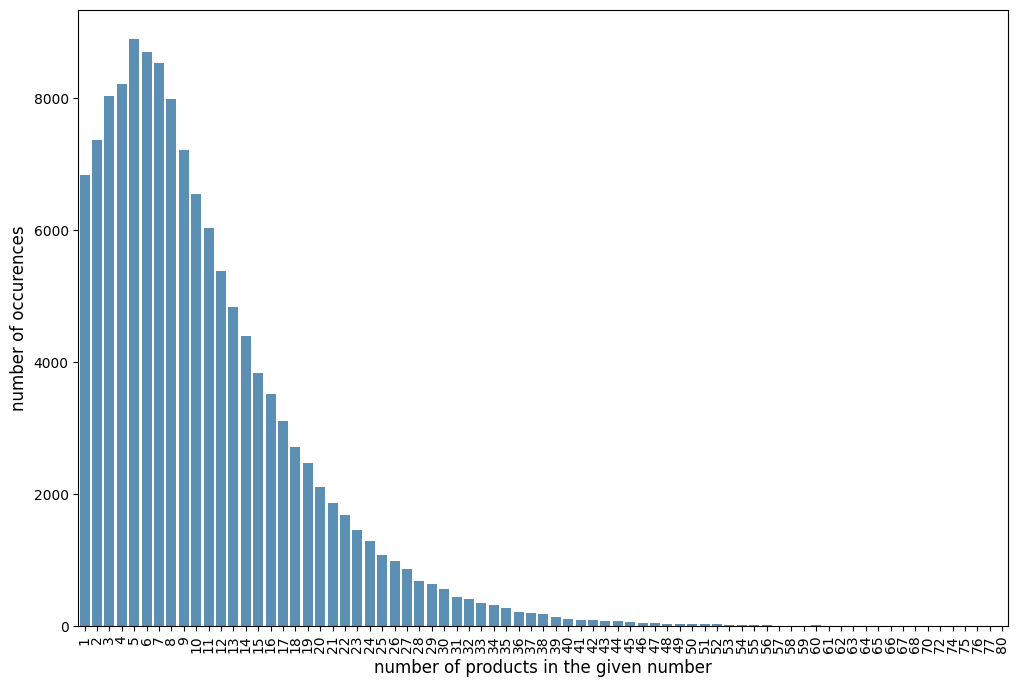

In [17]:
grouped_df=order_products_train_df.groupby('order_id')['add_to_cart_order'].aggregate('max').reset_index()
cnt_srs=grouped_df.add_to_cart_order.value_counts()
plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index,y=cnt_srs.values,alpha=0.8)
plt.ylabel('number of occurences',fontsize=12)
plt.xlabel('number of products in the given number',fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

In [18]:
products_df.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [44]:
aisles_df.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [45]:
departments_df.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [9]:
order_products_prior_df=pd.merge(order_products_prior_df,products_df,on='product_id',how='left')
order_products_prior_df=pd.merge(order_products_prior_df,aisles_df,on='aisle_id',how='left')
order_products_prior_df=pd.merge(order_products_prior_df,departments_df,on='department_id',how='left')
order_products_prior_df.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry


In [10]:
cnt_srs=order_products_prior_df['product_name'].value_counts().reset_index()
cnt_srs.columns=['product_name','frequency_count']
cnt_srs

,product_name,frequency_count
0,Banana,472565
1,Bag of Organic Bananas,379450
2,Organic Strawberries,264683
3,Organic Baby Spinach,241921
4,Organic Hass Avocado,213584
...,...,...
49672,Organic Finely Shredded Sharp Cheddar Cheese,1
49673,Cajun Sides Dirty Rice,1
49674,Piquillo & Jalapeno Bruschetta,1
49675,Original Jerky,1


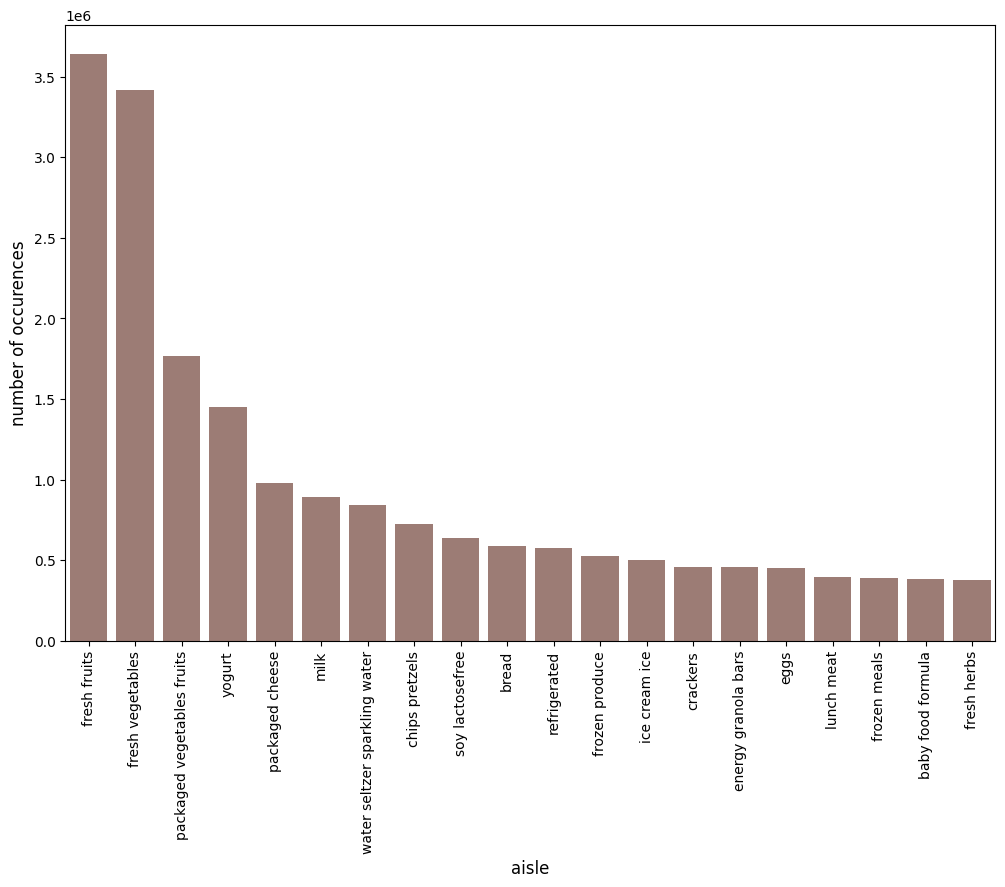

In [15]:
cnt_srs=order_products_prior_df['aisle'].value_counts().head(20)
plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index,y=cnt_srs.values,alpha=0.8,color=color[5])
plt.ylabel('number of occurences',fontsize=12)
plt.xlabel('aisle',fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

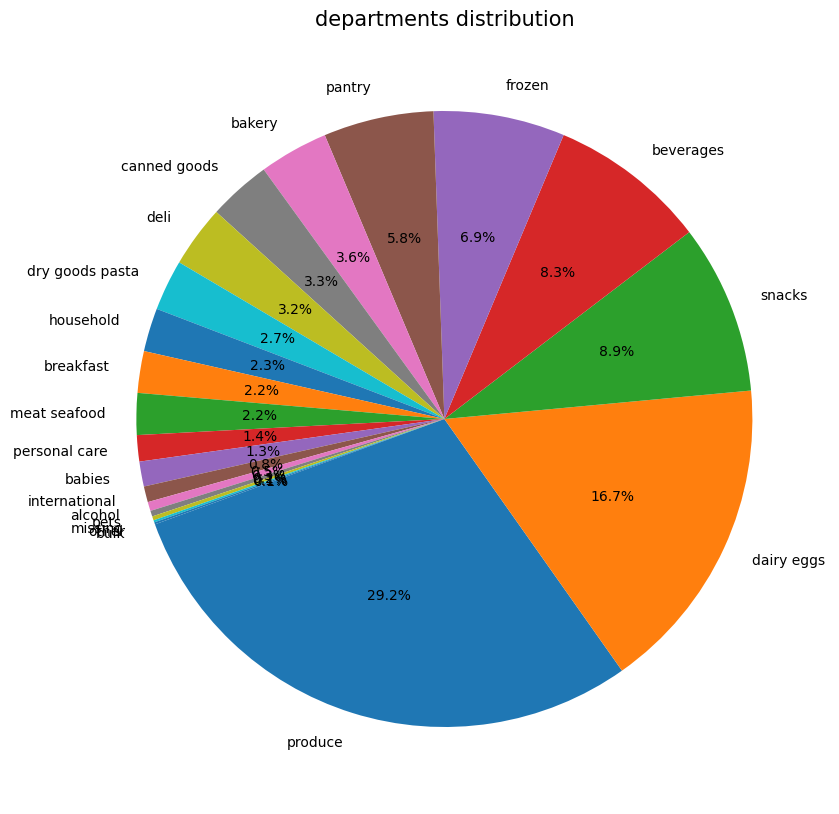

In [16]:
plt.figure(figsize=(10,10))
temp_series=order_products_prior_df['department'].value_counts()
labels=(np.array(temp_series.index))
sizes=(np.array((temp_series/temp_series.sum())*100))
plt.pie(sizes,labels=labels,autopct='%1.1f%%',startangle=200)
plt.title('departments distribution',fontsize=15)
plt.show()

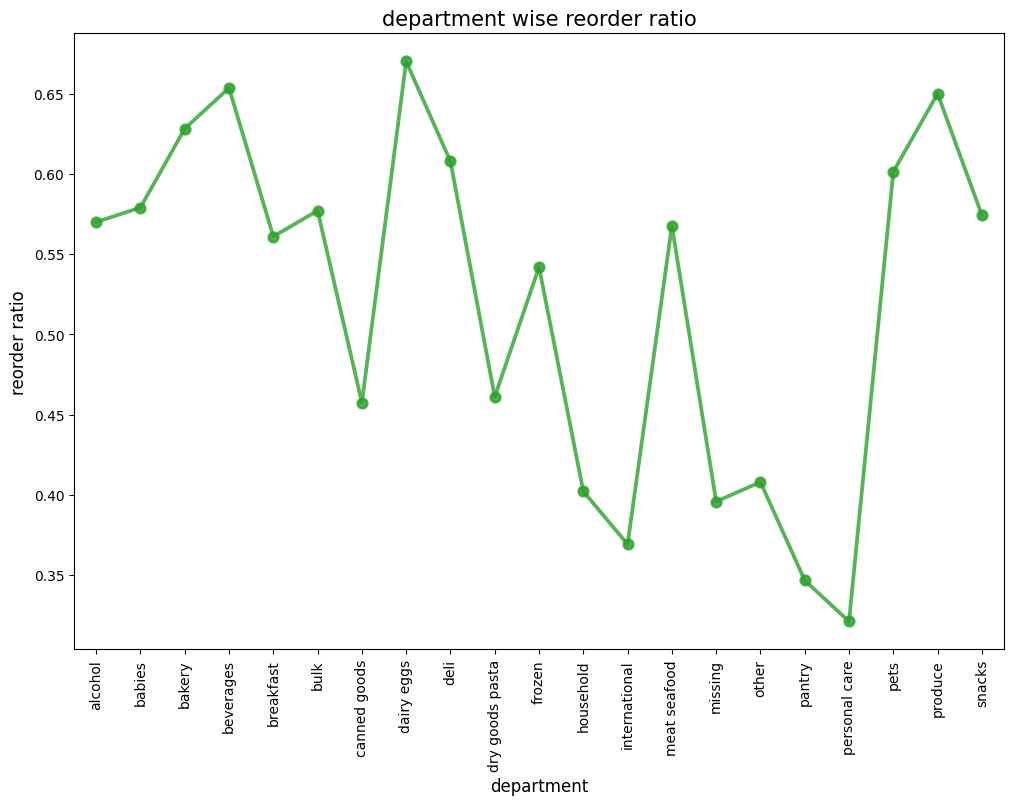

In [18]:
grouped_df=order_products_prior_df.groupby(['department'])['reordered'].aggregate('mean').reset_index()
plt.figure(figsize=(12,8))
sns.pointplot(x=grouped_df['department'].values,y=grouped_df['reordered'].values,alpha=0.8,color=color[2])
plt.ylabel('reorder ratio',fontsize=12)
plt.xlabel('department',fontsize=12)
plt.xticks(rotation='vertical')
plt.title('department wise reorder ratio',fontsize=15)
plt.show()

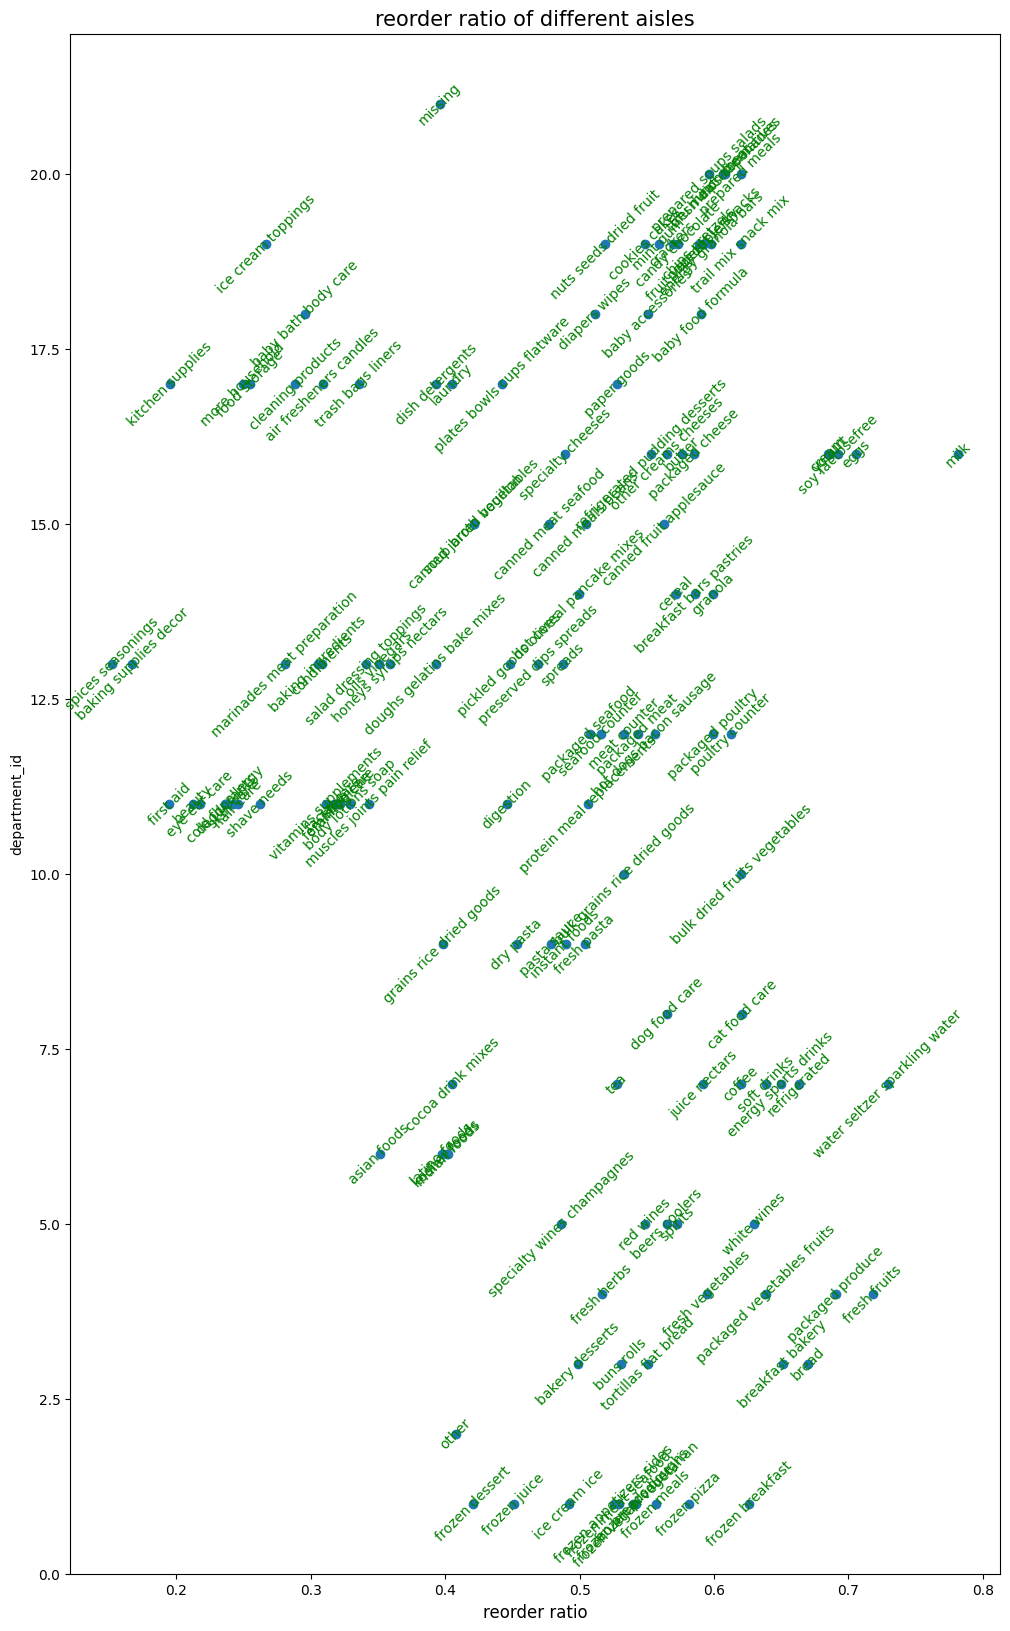

In [21]:
grouped_df=order_products_prior_df.groupby(['department_id','aisle'])['reordered'].aggregate('mean').reset_index()
fig,ax=plt.subplots(figsize=(12,20))
ax.scatter(grouped_df.reordered.values,grouped_df.department_id.values)
for i, txt in enumerate(grouped_df.aisle.values):
  ax.annotate(txt,(grouped_df.reordered.values[i],grouped_df.department_id.values[i]),rotation=45,ha='center',va='center',color='green')
plt.xlabel('reorder ratio',fontsize=12)
plt.xlabel('reorder ratio')
plt.ylabel('department_id')
plt.title('reorder ratio of different aisles',fontsize=15)
plt.show()

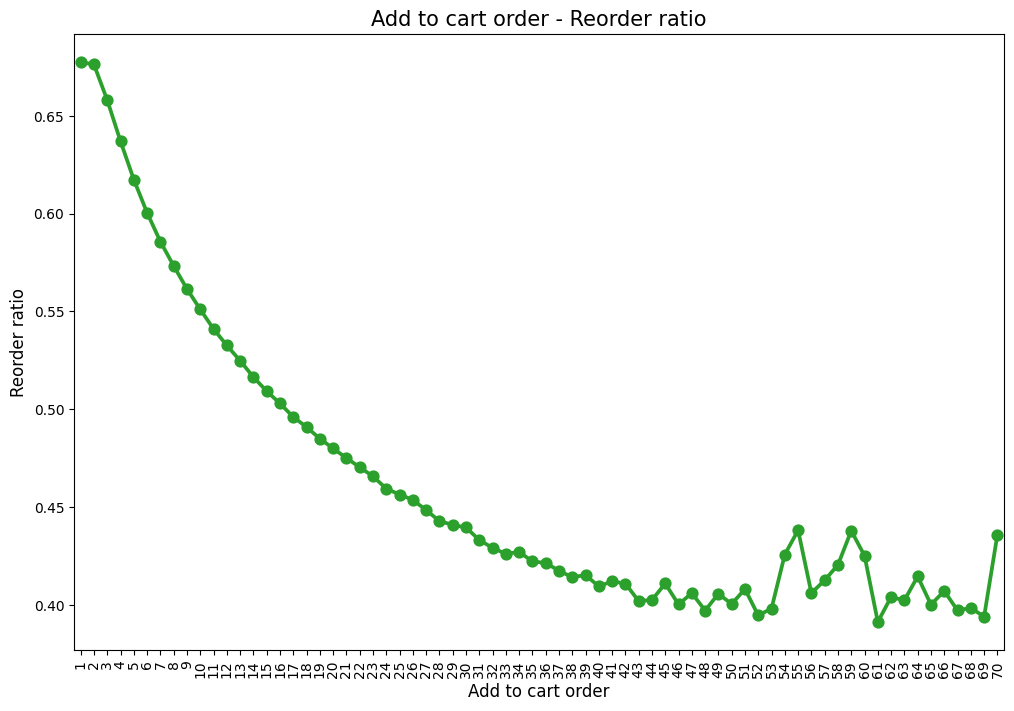

In [8]:
order_products_prior_df["add_to_cart_order_mod"] = order_products_prior_df["add_to_cart_order"].copy()
order_products_prior_df.loc[order_products_prior_df["add_to_cart_order_mod"] > 70, "add_to_cart_order_mod"] = 70
grouped_df = order_products_prior_df.groupby(["add_to_cart_order_mod"])["reordered"].aggregate("mean").reset_index()

plt.figure(figsize=(12, 8))
sns.pointplot(x=grouped_df['add_to_cart_order_mod'].values,
              y=grouped_df['reordered'].values,
              color=color[2])
plt.ylabel('Reorder ratio', fontsize=12)
plt.xlabel('Add to cart order', fontsize=12)
plt.title("Add to cart order - Reorder ratio", fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

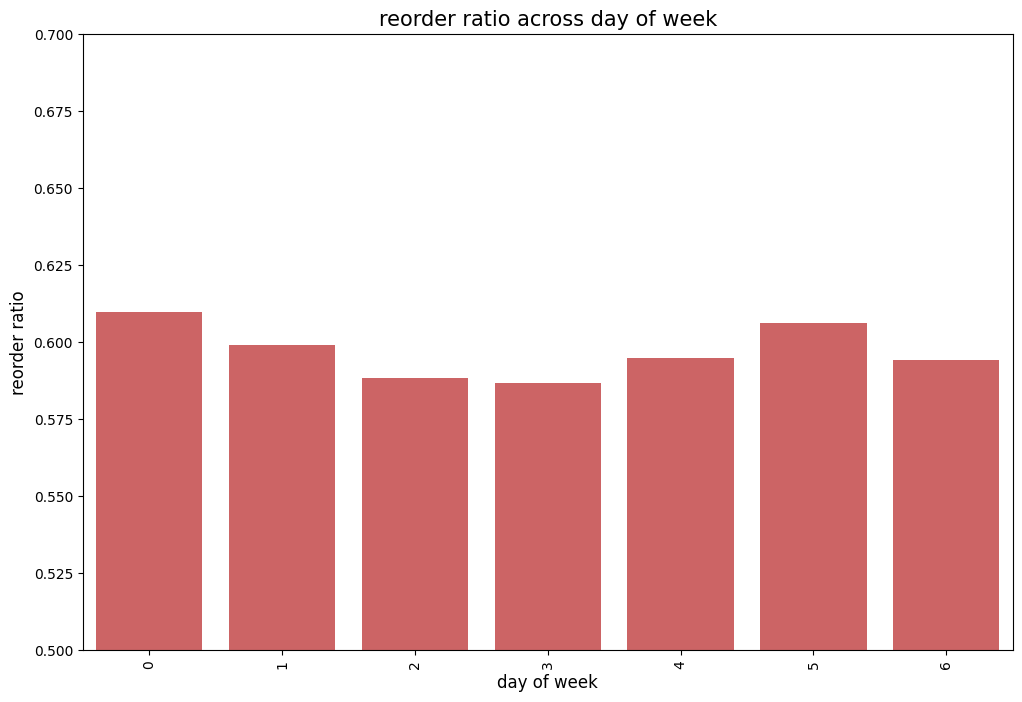

In [9]:
order_products_train_df=pd.merge(order_products_train_df,orders_df,on='order_id',how='left')
grouped_df=order_products_train_df.groupby(['order_dow'])['reordered'].aggregate('mean').reset_index()
plt.figure(figsize=(12,8))
sns.barplot(x=grouped_df['order_dow'].values,y=grouped_df['reordered'].values,alpha=0.8,color=color[3])
plt.ylabel('reorder ratio',fontsize=12)
plt.xlabel('day of week',fontsize=12)
plt.xticks(rotation='vertical')
plt.title('reorder ratio across day of week',fontsize=15)
plt.ylim(0.5,0.7)
plt.show()

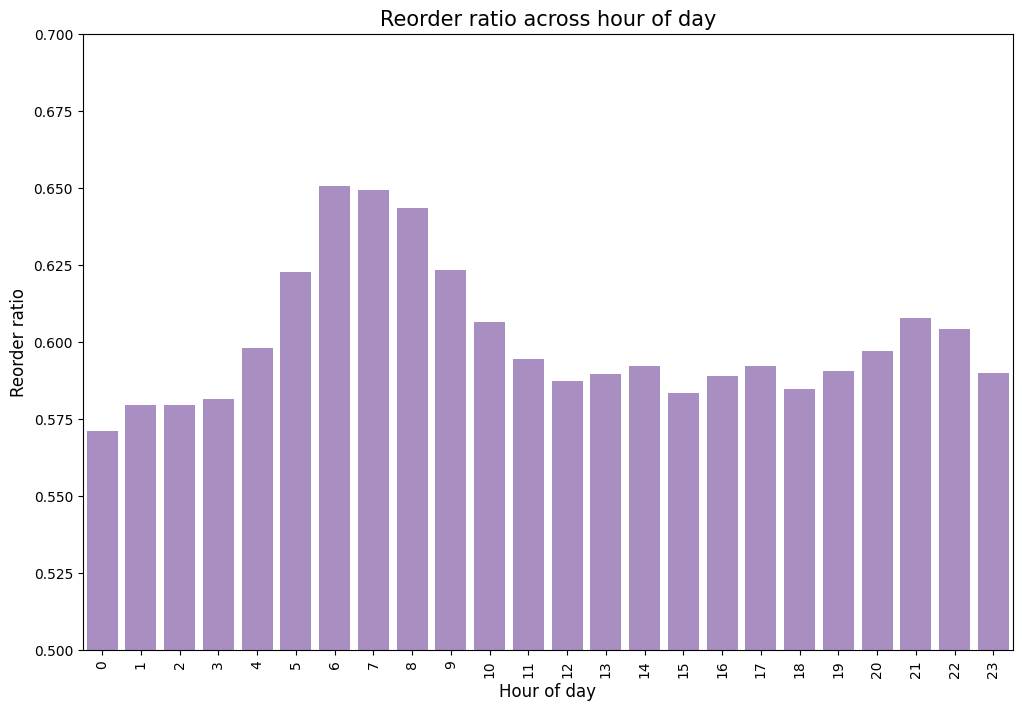

In [20]:
grouped_df = order_products_train_df.groupby(['order_hour_of_day'])['reordered'].aggregate('mean').reset_index()
plt.figure(figsize=(12, 8))
sns.barplot(x=grouped_df['order_hour_of_day'].values, y=grouped_df['reordered'].values, alpha=0.8, color=color[4])
plt.ylabel('Reorder ratio', fontsize=12)
plt.xlabel('Hour of day', fontsize=12)
plt.title('Reorder ratio across hour of day', fontsize=15)
plt.xticks(rotation='vertical')
plt.ylim(0.5, 0.7)
plt.show()

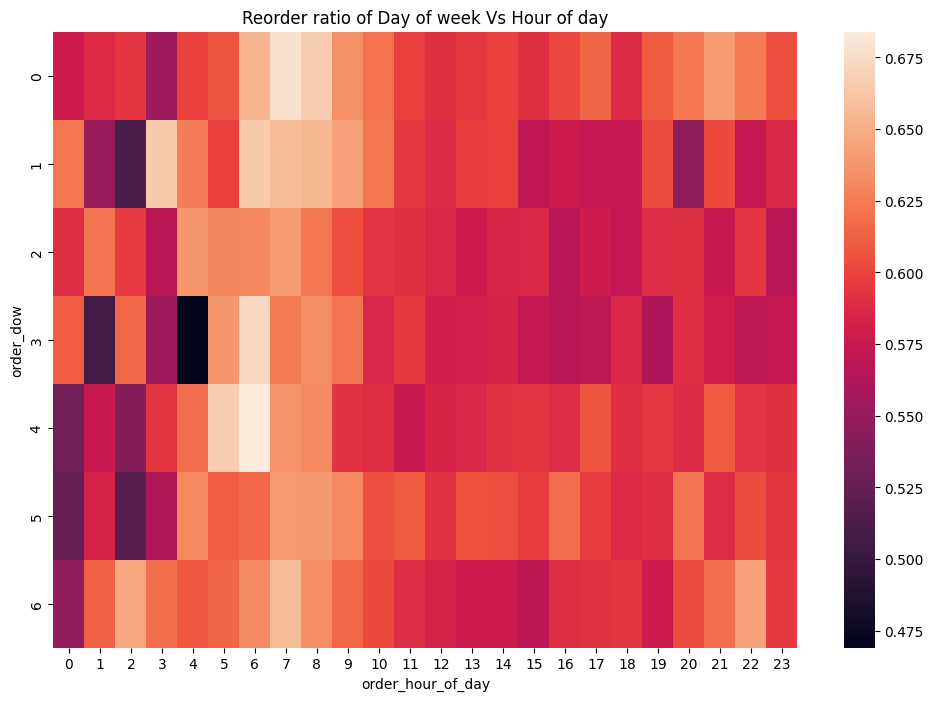

In [18]:
grouped_df = order_products_train_df.groupby(['order_dow', 'order_hour_of_day'])['reordered'].aggregate('mean').reset_index()
grouped_df = grouped_df.pivot(index='order_dow', columns='order_hour_of_day', values='reordered')
plt.figure(figsize=(12, 8))
sns.heatmap(grouped_df)
plt.title('Reorder ratio of Day of week Vs Hour of day')
plt.show()

새로운 시각화 제안:사용자별 재주문 비율 분포

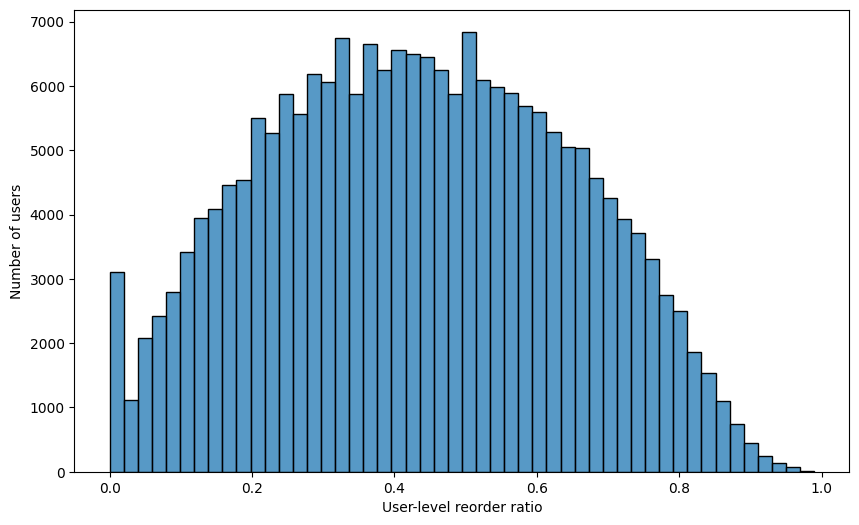

In [21]:
user_reorder = (order_products_prior_df
                .merge(orders_df[['order_id', 'user_id']], on='order_id', how='left')
                .groupby('user_id')['reordered'].mean())

plt.figure(figsize=(10, 6))
sns.histplot(user_reorder, bins=50)        # histplot = histogram(도수분포표) 그래프
plt.xlabel('User-level reorder ratio')
plt.ylabel('Number of users')
plt.show()

평균 59%"가 "평균적인 사용자가 59%"라는 뜻이 아니라는 것을 보여줌

판매량 vs 재주문 비율 산점도

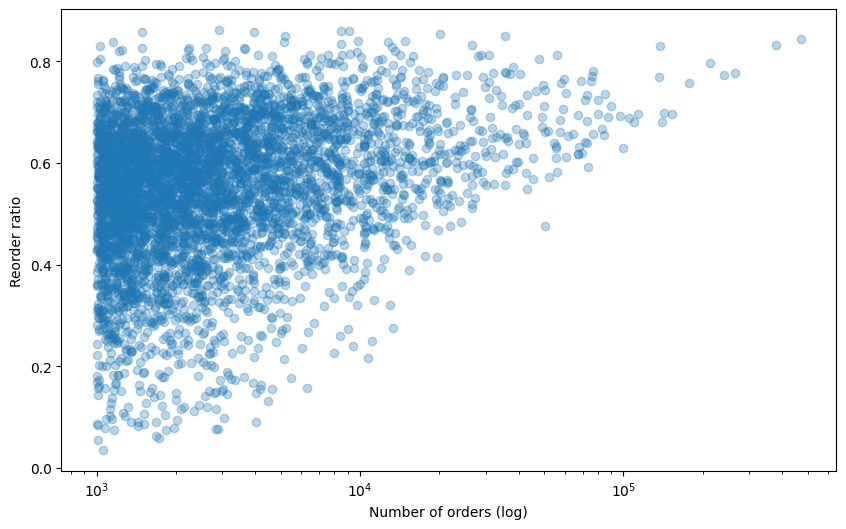

In [24]:
prod = (order_products_prior_df.groupby('product_name')
        .agg(n=('reordered', 'size'), ratio=('reordered', 'mean'))
        .query('n >= 1000'))          # 1000번 이상 팔린 상품만

plt.figure(figsize=(10, 6))
plt.scatter(prod['n'], prod['ratio'], alpha=0.3)
plt.xscale('log')                     # 판매량 차이가 커서 로그 축
plt.xlabel('Number of orders (log)')
plt.ylabel('Reorder ratio')
plt.show()

재주문 비율은 상품 특성에 따라 0.05에서 0.85까지 벌어지며, 판매량이 큰 상품일수록 높게 나타나지만 매량이 작은 상품의 비율은 표본이 작아 불안정하므로, 상품별 비율을 비교할 때는 판매 건수를 함께 봐야함